# Naive Bayes (Bag of Words) — MBTI Binary Dimensions

This notebook trains four binary Multinomial Naive Bayes classifiers (one per MBTI dimension) using Bag of Words vectorization.

## Overview

**Objective:** Predict each of the four MBTI dimensions independently:
- Introversion (I) vs. Extraversion (E)
- Intuition (N) vs. Sensing (S)
- Thinking (T) vs. Feeling (F)
- Judging (J) vs. Perceiving (P)


## 1 - Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from imblearn.over_sampling import RandomOverSampler

print("Packages imported successfully!")

Packages imported successfully!


## 2 - Load Data

Load the preprocessed MBTI dataset. The data contains:
- **posts**: Concatenated text posts from each user
- **type**: 4-letter MBTI type (e.g., "INFJ", "ENTP")

We use a flexible path search to ensure the notebook works across different team member environments.

In [2]:
print("Loading data...")
current_dir = Path.cwd()
csv_path = None
for parent in [current_dir] + list(current_dir.parents)[:3]:
    candidate = parent / 'data' / 'processed' / 'preprocessed_data.csv'
    if candidate.exists():
        csv_path = candidate
        break
if not csv_path:
    csv_path = Path(r"C:\Users\piete\Documents\ML_MBTI_project\data\processed\preprocessed_data.csv")

df = pd.read_csv(csv_path)
df = df.dropna(subset=['posts', 'type'])
print(f"Data loaded successfully! Shape: {df.shape}")

Loading data...
Data loaded successfully! Shape: (8462, 5)


## 3 - Vectorization (Bag of Words)

- `stop_words='english'`: Remove common words like "the", "is", "and" that don't carry personality information

**Bag of Words (BoW) Approach:**- `max_features=2000`: Keep top 2000 most frequent words (reduces dimensionality)

- Represents text as word frequency counts**Parameters:**

- Each document becomes a vector where each dimension represents a word

- Value = how many times that word appears- Generally faster to compute

- Simple but effective for text classification- Complements TF-IDF approach for comparison

- For personality detection, word repetition patterns may be significant

**Why BoW instead of TF-IDF?**- BoW preserves raw frequency information

In [3]:
print("Vectorizing text using Bag of Words (CountVectorizer)...")

# We use CountVectorizer instead of TfidfVectorizer
# max_features=2000 ensures we keep the model size manageable
vectorizer = CountVectorizer(max_features=2000, stop_words='english')
X = vectorizer.fit_transform(df['posts'])
y = df['type'].values

print(f"Data Ready! Features shape: {X.shape}")

Vectorizing text using Bag of Words (CountVectorizer)...
Data Ready! Features shape: (8462, 2000)


## 4 - Train & Evaluate Models

### 4.1 Naive Bayes Theory

**Multinomial Naive Bayes:**

Based on Bayes' Theorem:
$$P(y|X) = \frac{P(X|y) \cdot P(y)}{P(X)}$$

For text classification:
$$P(y|x_1, ..., x_n) \propto P(y) \prod_{i=1}^{n} P(x_i|y)$$

where:
- $y$ is the class (e.g., I or E)
- $x_i$ are the word features
- "Naive" assumption: features are conditionally independent given the class

**Why Multinomial NB for text?**
- Designed for discrete features (word counts)
- Fast training and prediction
- Works well with high-dimensional sparse data (text)
- Performs surprisingly well despite the "naive" independence assumption

**Regularization (alpha parameter):**
- `alpha=5.0`: Laplace smoothing parameter
- Prevents zero probabilities for unseen words
- Higher alpha = more smoothing = less overfitting
- Default is 1.0, we use 5.0 for stronger regularization

### 4.2 Training Strategy

We train four separate binary classifiers, one for each MBTI dimension.

**Class Imbalance Handling:**
- RandomOverSampler: Duplicates minority class samples to balance classes
- Critical for Naive Bayes which can be sensitive to imbalanced data
- Applied before train/test split to maintain realistic test distribution

**Train/Test Split:**
- 80% training, 20% testing
- Stratified split maintains class proportions
- Fixed random_state=42 for reproducibility

**Evaluation Metrics:**
- **Accuracy**: Overall correct predictions
- **F1-Score (Macro)**: Harmonic mean of precision and recall, averaged across classes
- **Confusion Matrix**: Detailed breakdown of predictions vs. actual labels
- **Overfitting Check**: Compare train vs. test accuracy (>5% gap indicates overfitting)

In [4]:
print("Starting Naive Bayes (BoW) Training...")

dimensions = [('I', 'E'), ('N', 'S'), ('T', 'F'), ('J', 'P')]
results = {}
results_detailed = {}
f1_scores = []

for trait1, trait2 in dimensions:
    print(f"\nProcessing {trait1} vs {trait2}")
    
    y_binary = np.array([1 if trait2 in label else 0 for label in y])
    
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X, y_binary)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_resampled, y_resampled, test_size=0.20, random_state=42
    )
    
    # Train with alpha for regularization
    clf = MultinomialNB(alpha=5.0)
    clf.fit(X_train, y_train)
    
    # Evaluate on both train and test sets
    train_preds = clf.predict(X_train)
    train_acc = accuracy_score(y_train, train_preds)
    
    test_preds = clf.predict(X_test)
    test_acc = accuracy_score(y_test, test_preds)

    # Calculate comprehensive metrics
    current_f1 = f1_score(y_test, test_preds, average='macro')
    precision = precision_score(y_test, test_preds, average='macro', zero_division=0)
    recall = recall_score(y_test, test_preds, average='macro', zero_division=0)
    overfit_gap = train_acc - test_acc
    
    # Cross-validation score
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(clf, X_resampled, y_resampled, cv=cv, scoring='accuracy')
    cv_score = cv_scores.mean()
    
    f1_scores.append(current_f1) 
    
    conf_mat = confusion_matrix(y_test, test_preds)
    
    dim_name = f"{trait1}/{trait2}"
    results[dim_name] = test_acc
    
    # Store detailed metrics for export
    results_detailed[dim_name] = {
        'model': clf,
        'accuracy': 100 * test_acc,
        'train_accuracy': 100 * train_acc,
        'f1_score': 100 * current_f1,
        'precision': 100 * precision,
        'recall': 100 * recall,
        'overfit_gap': 100 * overfit_gap,
        'cv_score': 100 * cv_score,
        'y_test': y_test,
        'y_pred': test_preds
    }
    
    # Display results with overfitting detection
    print(f"   Train Accuracy: {train_acc:.2%}")
    print(f"   Test Accuracy:  {test_acc:.2%}")
    print(f"   F1-Score:       {current_f1:.2%}")
    print(f"   Precision:      {precision:.2%}")
    print(f"   Recall:         {recall:.2%}")
    print(f"   Difference:     {overfit_gap:.2%}")
    if overfit_gap > 0.05:
        print(f"   Possible overfitting detected!")
    print(f"   CV Score:       {cv_score:.2%}")
    print(f"   Confusion Matrix:\n{conf_mat}")

# Summary statistics
total_accuracy = sum(results.values())
avg_accuracy = total_accuracy / len(results)
avg_f1 = sum(f1_scores) / len(f1_scores)
print(f"\nTotal Sum of Accuracies: {total_accuracy:.4f}")
print(f"Average Accuracy: {avg_accuracy:.2%}")
print(f"Average F1 Score: {avg_f1:.4f}")

Starting Naive Bayes (BoW) Training...

Processing I vs E
   Train Accuracy: 70.43%
   Test Accuracy:  68.25%
   F1-Score:       68.24%
   Precision:      68.26%
   Recall:         68.25%
   Difference:     2.18%
   CV Score:       67.62%
   Confusion Matrix:
[[905 401]
 [429 879]]

Processing N vs S
   Train Accuracy: 75.50%
   Test Accuracy:  74.23%
   F1-Score:       74.23%
   Precision:      74.25%
   Recall:         74.25%
   Difference:     1.27%
   CV Score:       73.08%
   Confusion Matrix:
[[1084  402]
 [ 349 1079]]

Processing T vs F
   Train Accuracy: 75.77%
   Test Accuracy:  75.36%
   F1-Score:       75.36%
   Precision:      75.36%
   Recall:         75.36%
   Difference:     0.41%
   CV Score:       73.62%
   Confusion Matrix:
[[681 230]
 [219 692]]

Processing J vs P
   Train Accuracy: 66.34%
   Test Accuracy:  61.26%
   F1-Score:       61.23%
   Precision:      61.27%
   Recall:         61.25%
   Difference:     5.08%
   Possible overfitting detected!
   CV Score:     

## 5 - Visualize Results

Each bar represents the test accuracy for one binary classification task.

Visualize model performance across all four MBTI dimensions to identify:

- Which dimensions are easier/harder to predict- Overall model effectiveness
- Consistency across different personality traits

Generating BoW Results Graph...


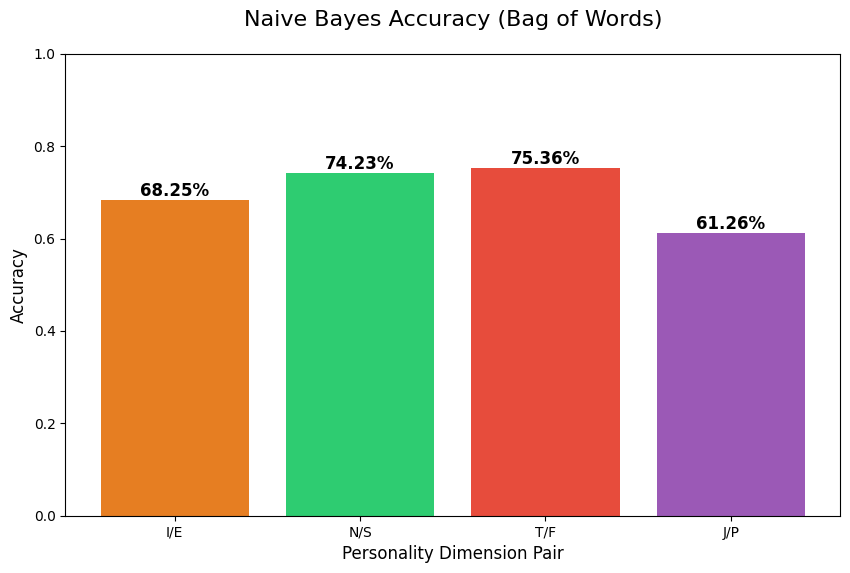

In [5]:
print("Generating BoW Results Graph...")

plt.figure(figsize=(10, 6))
keys = list(results.keys())
values = list(results.values())

# Using a slightly different color palette to distinguish from TF-IDF
bars = plt.bar(keys, values, color=['#e67e22', '#2ecc71', '#e74c3c', '#9b59b6'])

plt.title('Naive Bayes Accuracy (Bag of Words)', fontsize=16, pad=20)
plt.xlabel('Personality Dimension Pair', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1.0) 

# Add percentages
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height,
             f'{height:.2%}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

## 6 - Save Models

Save trained models with comprehensive metrics for comparison with SVM and Logistic Regression.

The saved file includes:
- Trained Naive Bayes classifier for each dimension
- Bag of Words vectorizer
- Comprehensive metrics (accuracy, F1, precision, recall, CV score, overfitting gap)
- Hyperparameters for reproducibility

In [6]:
print("Saving Naive Bayes (BoW) models with comprehensive metrics...")

model_data = {
    'dimensions': list(results_detailed.keys()),
    'models': {dim: results_detailed[dim]['model'] for dim in results_detailed},
    'accuracies': {dim: results_detailed[dim]['accuracy'] / 100 for dim in results_detailed},
    # Comprehensive metrics
    'metrics': {dim: {
        'accuracy': results_detailed[dim]['accuracy'],
        'f1_score': results_detailed[dim]['f1_score'],
        'precision': results_detailed[dim]['precision'],
        'recall': results_detailed[dim]['recall'],
        'train_accuracy': results_detailed[dim]['train_accuracy'],
        'overfit_gap': results_detailed[dim]['overfit_gap'],
        'cv_score': results_detailed[dim]['cv_score']
    } for dim in results_detailed},
    'vectorizer': vectorizer,
    'model_type': 'Naive Bayes (Bag of Words)',
    'hyperparameters': {'alpha': 5.0, 'upsampling': True}
}

joblib.dump(model_data, '../models/naive_bayes_BOW.pkl')
print("Models saved to '../models/naive_bayes_BOW.pkl'")

print(f"\nSaved {len(results_detailed)} Naive Bayes (BoW) models:")
for dim in results_detailed.keys():
    print(f"  - {dim}: Accuracy={results_detailed[dim]['accuracy']:.2f}%, F1={results_detailed[dim]['f1_score']:.2f}%")

Saving Naive Bayes (BoW) models with comprehensive metrics...
Models saved to '../models/naive_bayes_BOW.pkl'

Saved 4 Naive Bayes (BoW) models:
  - I/E: Accuracy=68.25%, F1=68.24%
  - N/S: Accuracy=74.23%, F1=74.23%
  - T/F: Accuracy=75.36%, F1=75.36%
  - J/P: Accuracy=61.26%, F1=61.23%
